In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa
import warnings
import matplotlib.colors as mcolors
import equinox as eqx
import jax
import jax.numpy as jnp

from hypermagnetics import plots
from hypermagnetics.sources import read_db
from hypermagnetics.models.hyper_mlp import HyperLayer
from hypermagnetics.fmm_sources import potential2D


warnings.filterwarnings('ignore')
plt.style.use(["science", "ieee"])

res = 32
lim = 1.2
idx = -1

/home/spol/miniconda3/envs/hm-test/lib/python3.11/site-packages/magtense/magstatics.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [2]:
data = read_db("train_res32_3D_42_200000_1.h5", max_samples=1000)
nan_count = np.isnan(data["field"]).sum()
print(f"Number of NaN values in data['field']: {nan_count}")
print(f"Max size: {data['max_size']}")
print(f"Min size: {data['min_size']}")

Number of NaN values in data['field']: 0
Max size: 0.49974626302719116
Min size: 0.05037396401166916


Magnet #-1: [[ 9.131466    4.6381774  11.043177   -0.16314897 -0.8300753  -0.49727648
   0.26471502  0.26471502  0.26471502]]


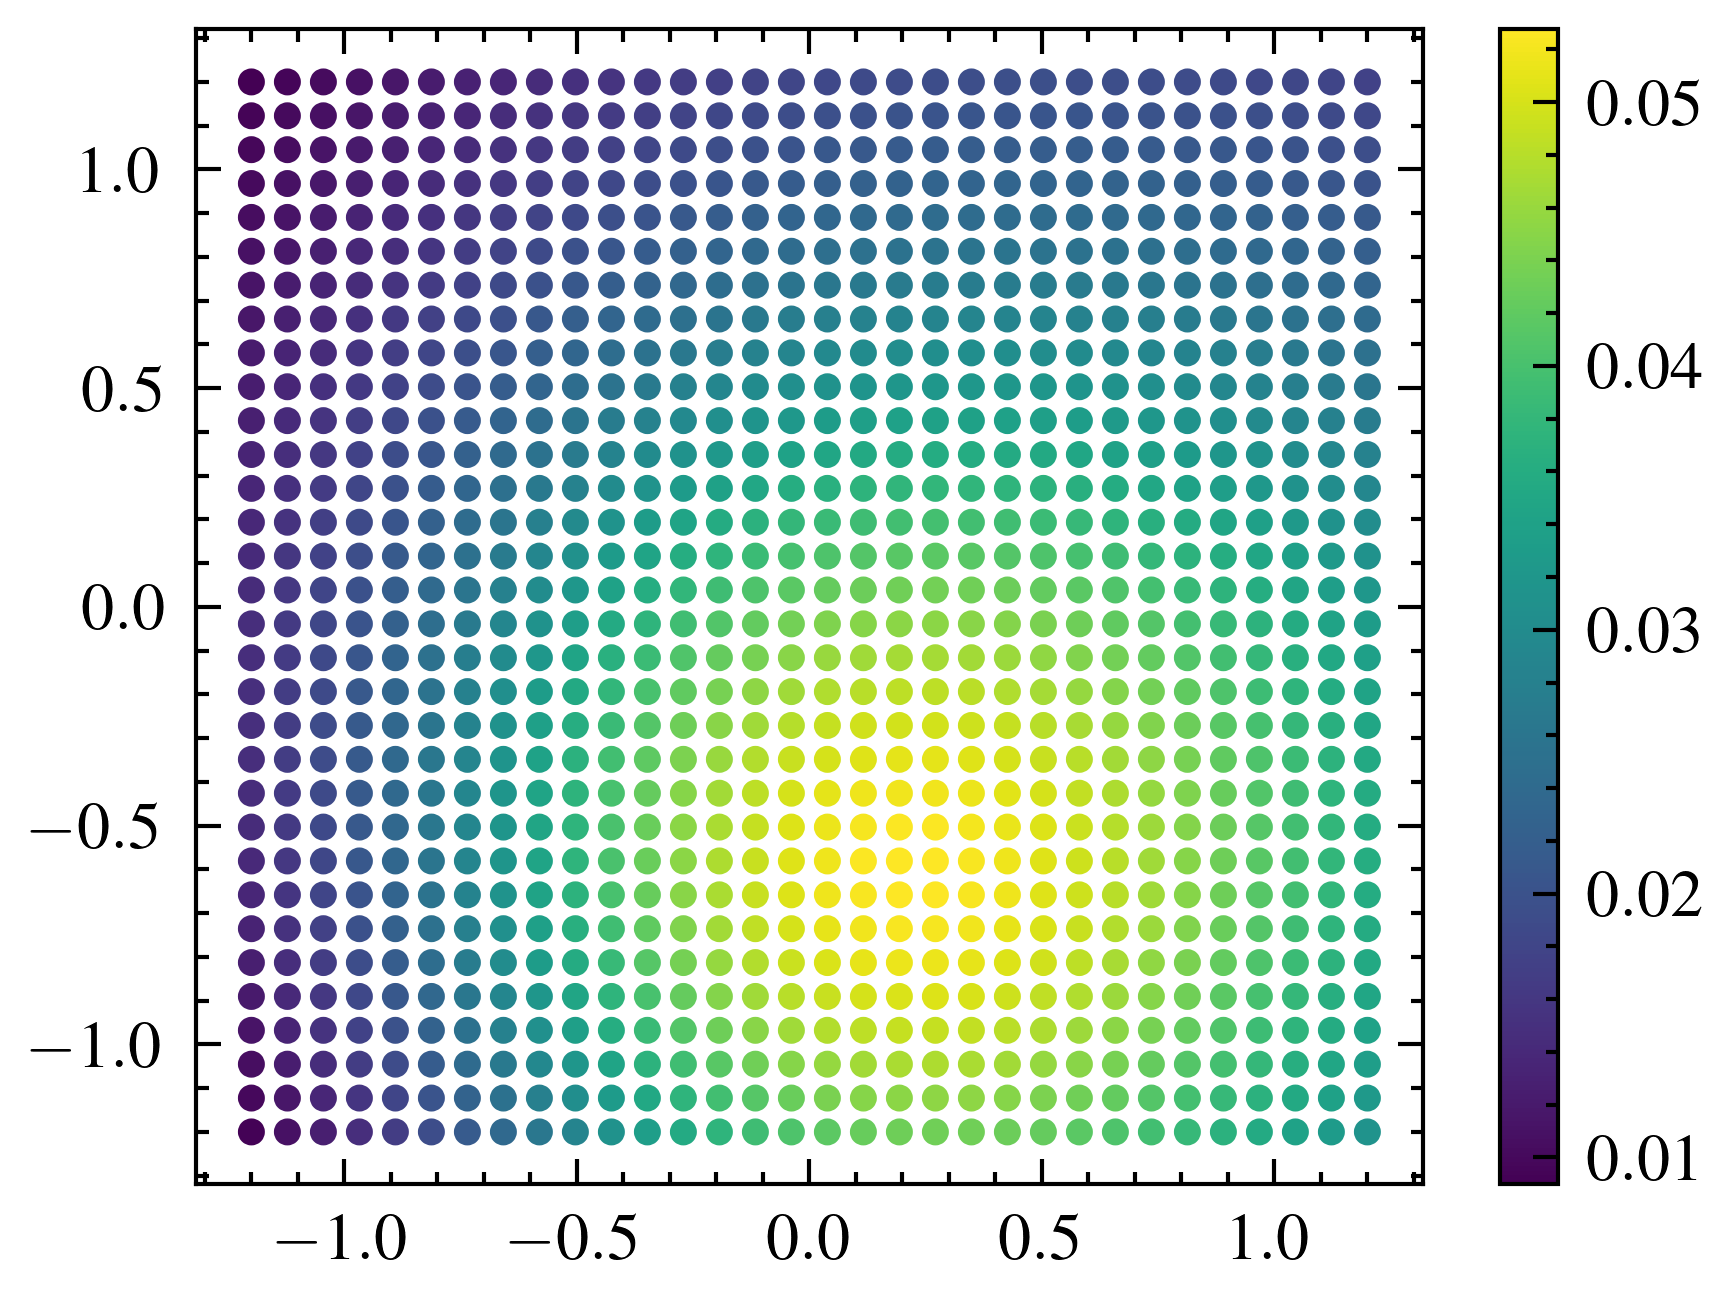

In [3]:
slice_idx = 30
grids = jnp.meshgrid(*[jnp.linspace(-lim, lim, res)] * 3)
grid = np.concatenate([g.ravel()[:, None] for g in grids], axis=-1)
x_grid = np.array(grid[:, 0].reshape((res, res, res)))[:, :, slice_idx]
y_grid = np.array(grid[:, 1].reshape((res, res, res)))[:, :, slice_idx]
contour = plt.scatter(x_grid, y_grid, c=data["msp_grid"][idx].reshape((res, res, res))[...,slice_idx], cmap='viridis', s=5)
plt.colorbar(contour)
print(f"Magnet #{idx}: {data['sources'][idx]}")